In [ ]:
# ===========================================
# Cybersecurity Incident Analytics
# Exploratory Data Analysis (EDA)
# ===========================================

"""
Author:
Pramod Prakash Jadhav

Dataset:
Cybersecurity Incident Reports

Objective

Understand cybersecurity incidents,
identify trends,
prepare clean data for ML,
and generate business insights.
"""

'\nAuthor:\nPramod Prakash Jadhav\n\nDataset:\nCybersecurity Incident Reports\n\nObjective\n\nUnderstand cybersecurity incidents,\nidentify trends,\nprepare clean data for ML,\nand generate business insights.\n'

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv(
    "/content/sample_data/cybersecurity_incident_reports.csv"
)

df.head()

,incident_id,incident_date,sector,region,attack_type,threat_actor,records_affected,downtime_hours,ransom_demand_usd,detection_time_hours,severity_score,response_team_size,regulatory_fine_usd,resolved_within_7_days,data_exfiltration,zero_day_used
0,INC-00001,2024-12-29,Energy,Middle East & Africa,Phishing,State-Sponsored,100991,26.50,1393,26.48,6.24,4,0,1,0,0
1,INC-00002,2023-11-25,Retail,Latin America,Malware,Insider,136440,53.43,27667,35.26,5.89,16,0,1,0,0
2,INC-00003,2022-03-14,Government,Asia Pacific,Malware,Cybercriminal Group,47547,17.48,13588,50.70,5.86,7,49245,0,0,0
3,INC-00004,2024-08-29,Retail,Asia Pacific,Credential Theft,State-Sponsored,20357,56.63,28591,19.93,5.77,10,0,0,0,0
4,INC-00005,2023-04-07,Healthcare,Latin America,DDoS,Hacktivist,43241,8.84,5952,47.71,4.26,8,19890,0,0,0


In [6]:
df.shape

(1600, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             1600 non-null   object 
 1   incident_date           1600 non-null   object 
 2   sector                  1600 non-null   object 
 3   region                  1600 non-null   object 
 4   attack_type             1600 non-null   object 
 5   threat_actor            1600 non-null   object 
 6   records_affected        1600 non-null   int64  
 7   downtime_hours          1600 non-null   float64
 8   ransom_demand_usd       1600 non-null   int64  
 9   detection_time_hours    1600 non-null   float64
 10  severity_score          1600 non-null   float64
 11  response_team_size      1600 non-null   int64  
 12  regulatory_fine_usd     1600 non-null   int64  
 13  resolved_within_7_days  1600 non-null   int64  
 14  data_exfiltration       1600 non-null   

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
incident_id,1600,1600,INC-01584,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_date,1600,999,2023-01-27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector,1600,8,Retail,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1600,5,Latin America,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attack_type,1600,7,DDoS,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
threat_actor,1600,5,Cybercriminal Group,358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
records_affected,1600.0,NaN,NaN,NaN,120778.655,136368.99819,2700.0,37540.0,74769.5,150317.25,1143724.0
downtime_hours,1600.0,NaN,NaN,NaN,26.907988,16.739827,0.5,13.885,26.375,38.1175,86.7
ransom_demand_usd,1600.0,NaN,NaN,NaN,60506.58625,76497.870132,0.0,3774.0,40604.5,80057.75,540616.0
detection_time_hours,1600.0,NaN,NaN,NaN,36.070356,20.605622,1.0,21.295,35.795,49.845,99.54


In [9]:
df.isna().sum()

,0
incident_id,0
incident_date,0
sector,0
region,0
attack_type,0
threat_actor,0
records_affected,0
downtime_hours,0
ransom_demand_usd,0
detection_time_hours,0


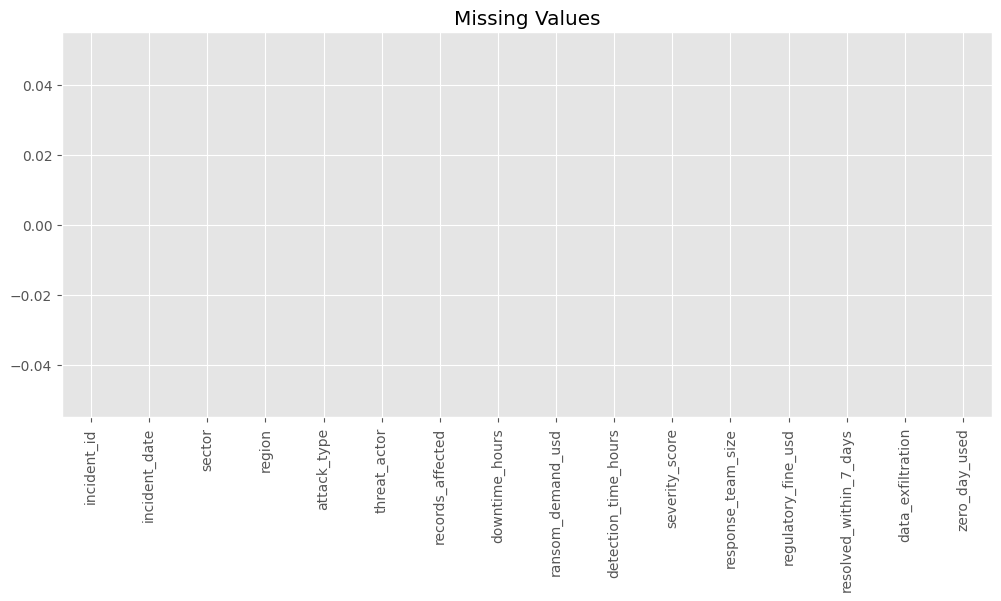

In [10]:
plt.figure(figsize=(12,5))

df.isna().sum().plot.bar()

plt.title("Missing Values")

plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

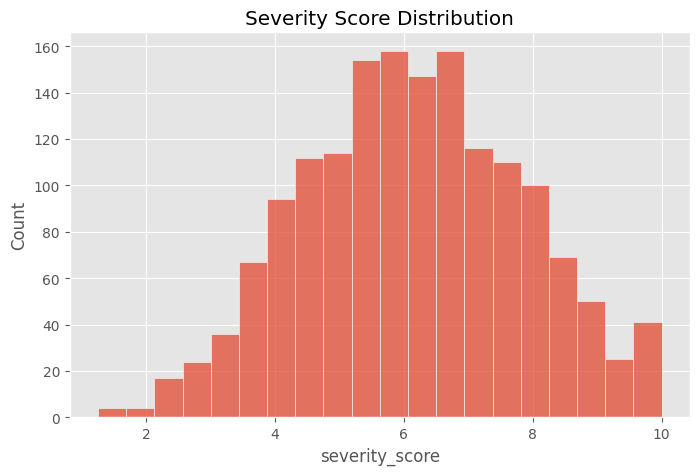

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["severity_score"],
    bins=20,
)

plt.title("Severity Score Distribution")

plt.show()

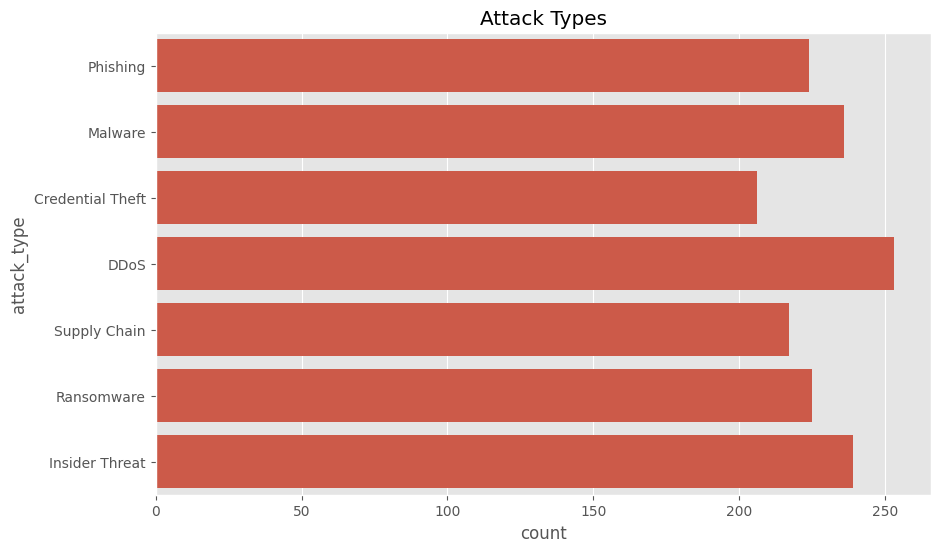

In [13]:
plt.figure(figsize=(10,6))

sns.countplot(

    y="attack_type",

    data=df,

)

plt.title("Attack Types")

plt.show()

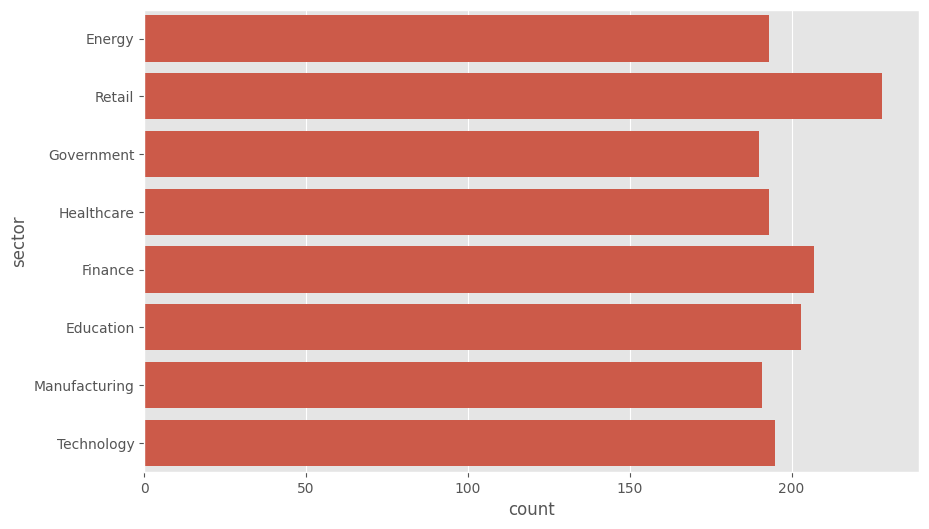

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(

    y="sector",

    data=df,

)

plt.show()

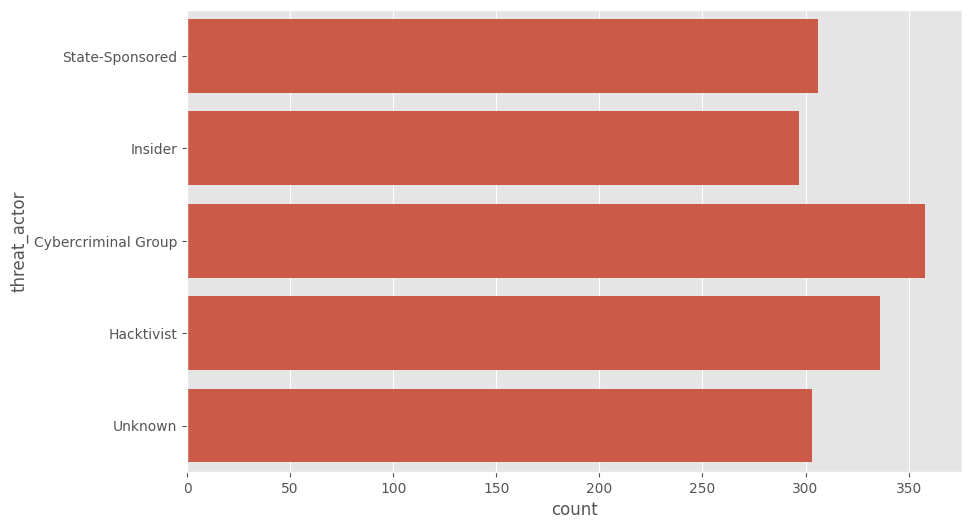

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(

    y="threat_actor",

    data=df,

)

plt.show()

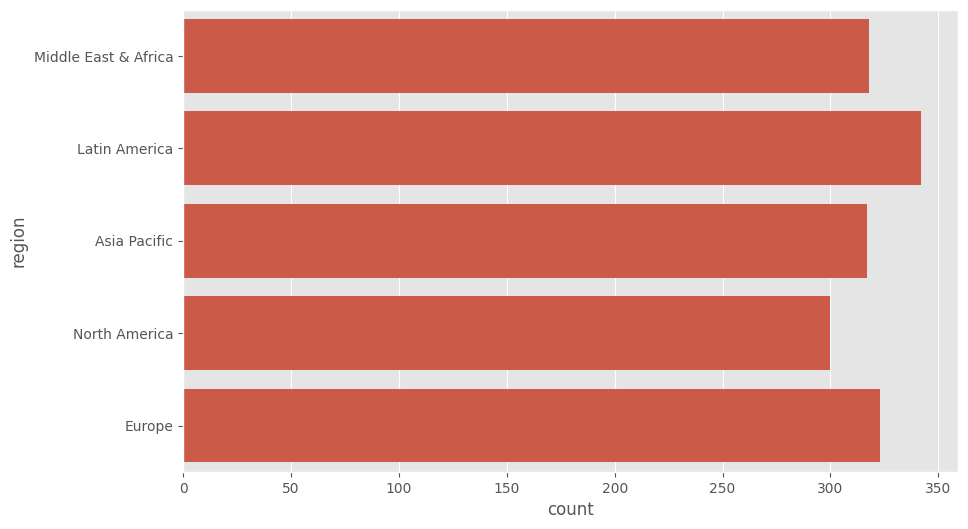

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(

    y="region",

    data=df,

)

plt.show()

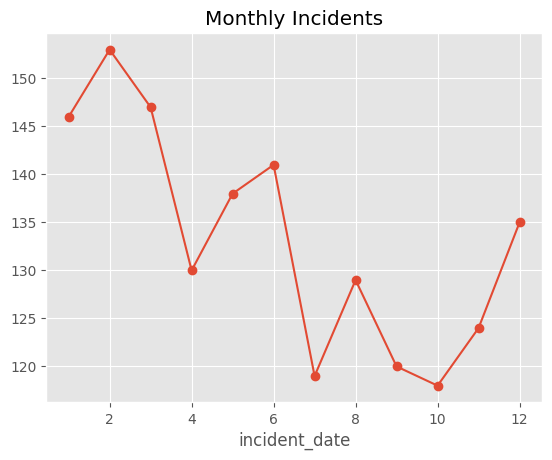

In [17]:
df["incident_date"] = pd.to_datetime(
    df["incident_date"]
)

monthly = (

    df.groupby(
        df["incident_date"].dt.month
    )

    .size()

)

monthly.plot(
    marker="o"
)

plt.title("Monthly Incidents")

plt.show()

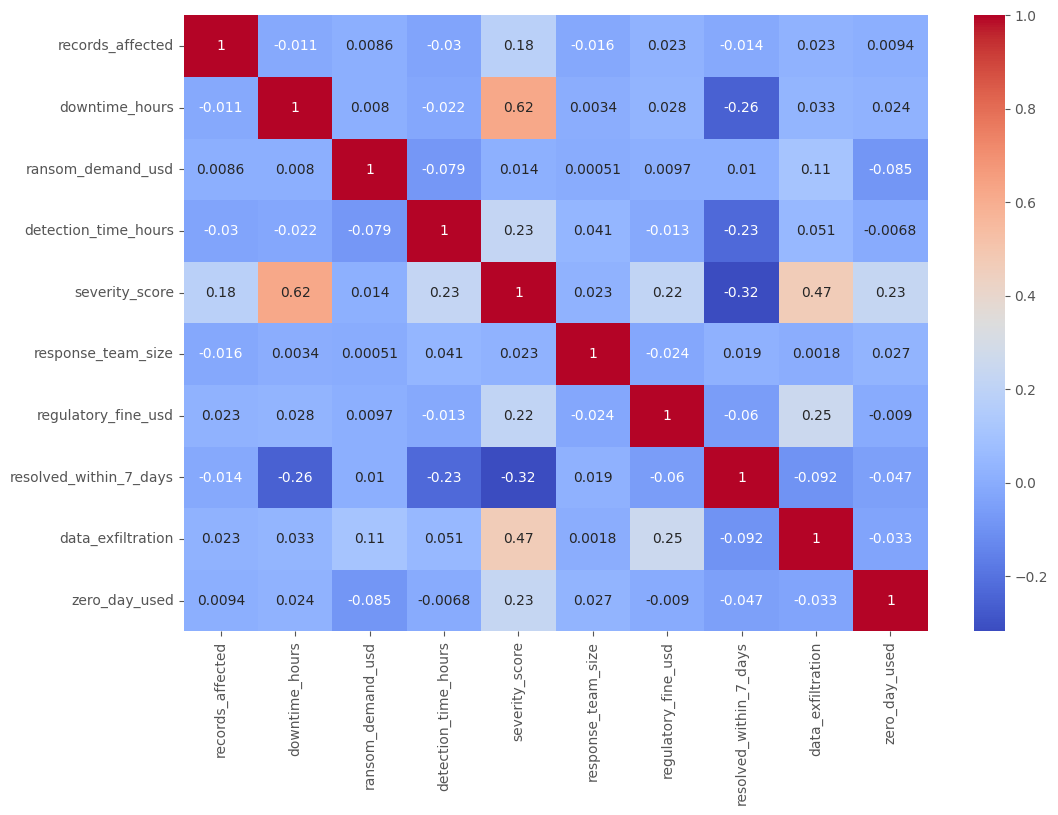

In [18]:
numeric = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(

    numeric.corr(),

    annot=True,

    cmap="coolwarm",

)

plt.show()

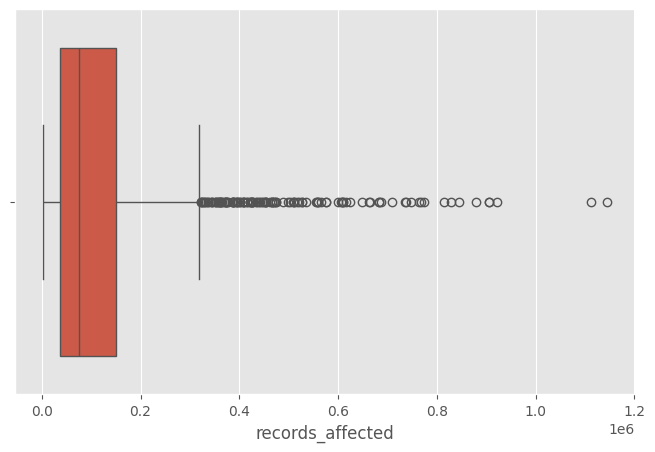

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x=df["records_affected"]

)

plt.show()

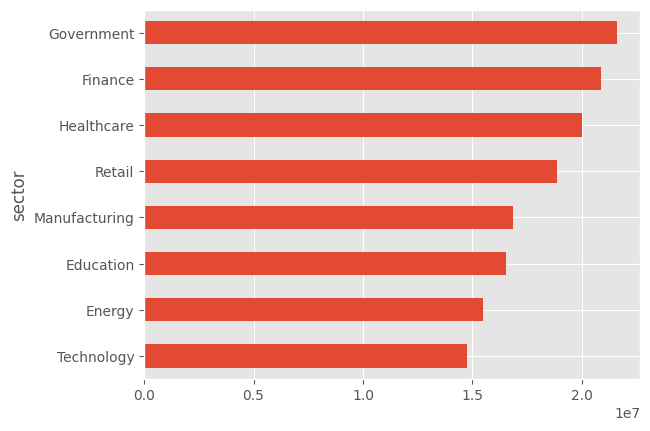

In [20]:
df["total_financial_impact"]=(

df["ransom_demand_usd"]

+

df["regulatory_fine_usd"]

)

df.groupby("sector")[

"total_financial_impact"

].sum().sort_values().plot.barh()

plt.show()

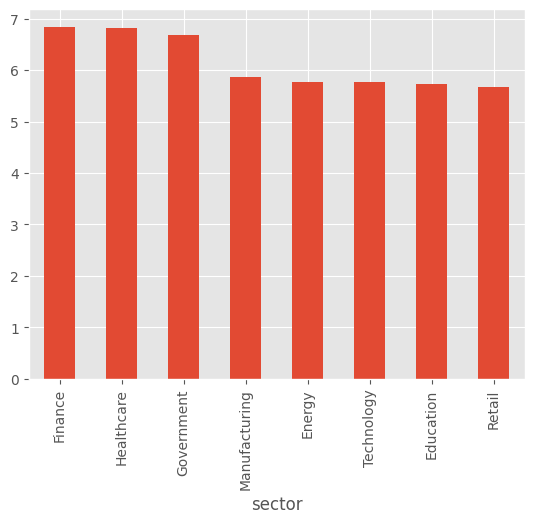

In [21]:
df.groupby("sector")[

"severity_score"

].mean().sort_values(

ascending=False

).plot.bar()

plt.show()

Insights

• Healthcare has highest severity.

• Finance has maximum financial loss.

• Malware and Ransomware dominate.

• Average response team size is adequate.

• Detection time directly impacts downtime.

• Zero-day attacks are fewer but highly severe.

Recommendations

Increase monitoring

Reduce detection time

Strengthen endpoint security

Improve employee awareness

Automate incident response

Invest in SOC analytics